In [1]:
import gwinc
import numpy as np
import matplotlib.pyplot as plt
from pykat.commands import *    
pykat.init_pykat_plotting(mode='display', fmts=['svg'])

from gwinc import squeeze

# Loading noise budget for ET-HF from GWINC
freq_ET=np.logspace(0, 5, 3000)
Budget_HF = gwinc.load_budget('ET_HF',freq=freq_ET)
Budget_HF.ifo.Squeezer.FilterCavity=squeeze.computeFCParams(Budget_HF.ifo)

# Calculating individual noise sources' PSDs
HF_traces = Budget_HF.run()
HF_qn = HF_traces['QuantumVacuum'].psd
HF_tn = HF_traces['SuspensionThermal'].psd
HF_bn = HF_traces['CoatingBrownian'].psd
HF_cn = HF_traces['CoatingThermoOptic'].psd
HF_sbn= HF_traces['SubstrateBrownian'].psd
HF_sTn = HF_traces['SubstrateThermoElastic'].psd
HF_nn = HF_traces['Newtonian'].psd
HF_sn = HF_traces['Seismic'].psd
HF_gp = HF_traces['ExcessGas'].psd
HF_tn = HF_traces['SuspensionThermal'].psd

# Calculating sum total noise fro ET-HF
HF_total=HF_qn+HF_tn+HF_bn+HF_cn+HF_sbn+HF_sTn+HF_nn+HF_sn

# Loading noise budget for ET-LF from GWINC
Budget_LF = gwinc.load_budget('ET_LF',freq=freq_ET)
Budget_LF.ifo.Squeezer.FilterCavity=squeeze.computeFCsParams(Budget_LF.ifo,Budget_LF.ifo.Squeezer.FilterCavity)

# Calculating individual noise sources' PSDs
LF_traces = Budget_LF.run()
LF_qn = LF_traces['QuantumVacuum'].psd
LF_tn = LF_traces['SuspensionThermal'].psd
LF_bn = LF_traces['CoatingBrownian'].psd
LF_cn = LF_traces['CoatingThermoOptic'].psd
LF_sbn=LF_traces['SubstrateBrownian'].psd
LF_sTn = LF_traces['SubstrateThermoElastic'].psd
LF_nn = LF_traces['Newtonian'].psd
LF_sn = LF_traces['Seismic'].psd
LF_gp = LF_traces['ExcessGas'].psd

# Calculating sum total noise fro ET-LF
LF_total=LF_qn+LF_tn+LF_bn+LF_cn+LF_sbn+LF_sTn+LF_nn+LF_sn

#Calculating total noise ETD=A*B/np.sqrt(A**2+B**2)
ET_total=(HF_total*LF_total)/(HF_total+LF_total)

                                              ..-
    PyKat 1.2.81          _                  '(
                          \`.|\.__...-""""-_." )
       ..+-----.._        /  ' `            .-'
   . '            `:      7/* _/._\    \   (
  (        '::;;+;;:      `-"' =" /,`"" `) /
  L.        \`:::a:f            c_/     n_'
  ..`--...___`.  .    ,
   `^-....____:   +.      www.gwoptics.org/pykat



In [2]:
# Load test curves from 2011 ET Design Study
Freq=np.loadtxt("ETDSensitivityCurve.txt")[:, 0]
A=np.loadtxt("ETDSensitivityCurve.txt")[:, 1]
B=np.loadtxt("ETDSensitivityCurve.txt")[:, 2]
C=np.loadtxt("ETDSensitivityCurve.txt")[:, 3]

Text(0, 0.5, 'Strain [$1 / \\sqrt{\\mathrm{Hz}}$]')

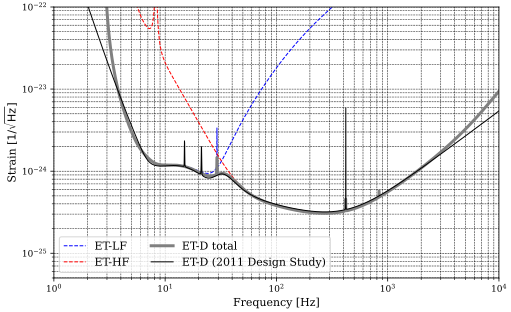

In [3]:
# Plot comparison of PyGWinc-ET and ET-D curve from 2011 Design study
fig = plt.figure(figsize=(8,5))
plt.loglog(freq_ET,np.sqrt(LF_total),
           freq_ET,np.sqrt(HF_total),linestyle='--',linewidth=1.0)
plt.loglog(freq_ET,np.sqrt(ET_total),'gray',linewidth=3.0)
plt.loglog(Freq,C,'k',linewidth=1.0)

plt.grid(which='both',color='k',linestyle='--',linewidth=0.5)

plt.legend(['ET-LF','ET-HF','ET-D total','ET-D (2011 Design Study)'],ncol=2)

plt.xlim(1,10000)

plt.ylim([5*10**(-26), 1*10**(-22)])

plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain [$1 / \sqrt{\mathrm{Hz}}$]')
#plt.savefig("ET-D_comparison_2021vs2011.pdf")

Text(0, 0.5, 'Strain [$1 / \\sqrt{\\mathrm{Hz}}$]')

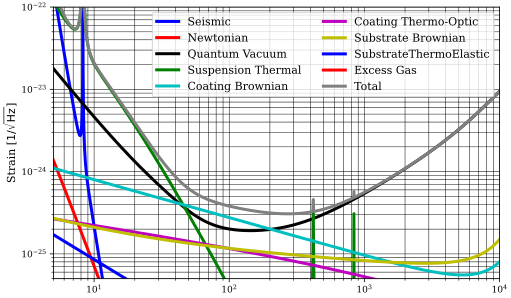

In [4]:
# Plot of noise budget for ET-HF
fig = plt.figure(figsize=(8,5))
plt.loglog(freq_ET,np.sqrt(HF_sn),freq_ET,np.sqrt(HF_nn),freq_ET,np.sqrt(HF_qn),freq_ET,np.sqrt(HF_tn),
           freq_ET,np.sqrt(HF_bn),freq_ET,np.sqrt(HF_cn), 
           freq_ET,np.sqrt(HF_sbn),freq_ET,np.sqrt(HF_sTn),freq_ET,np.sqrt(HF_gp),
           freq_ET,np.sqrt(HF_total),'gray',linewidth=3.0)


plt.grid(which='both',color='k',linestyle='-',linewidth=0.5)
plt.legend(['Seismic','Newtonian','Quantum Vacuum','Suspension Thermal','Coating Brownian','Coating Thermo-Optic',
            'Substrate Brownian','SubstrateThermoElastic','Excess Gas','Total'],ncol=2)


plt.xlim(5,10000)
plt.ylim([5*10**(-26), 1*10**(-22)])
plt.ylabel('Strain [$1 / \sqrt{\mathrm{Hz}}$]')
#plt.savefig("ETHF.pdf")

Text(0, 0.5, 'Strain [$1 / \\sqrt{\\mathrm{Hz}}$]')

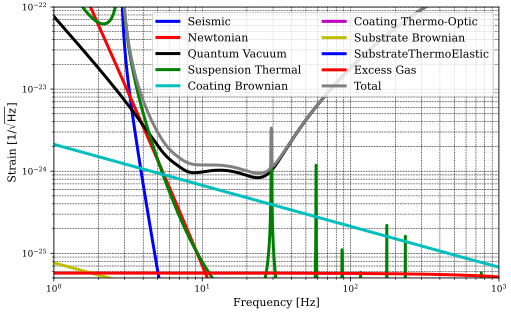

In [5]:
# Plot of noise budget for ET-LF
fig = plt.figure(figsize=(8,5))
plt.loglog(freq_ET,np.sqrt(LF_sn),freq_ET,np.sqrt(LF_nn),freq_ET,np.sqrt(LF_qn),freq_ET,np.sqrt(LF_tn),
           freq_ET,np.sqrt(LF_bn),freq_ET,np.sqrt(LF_cn), 
           freq_ET,np.sqrt(LF_sbn),freq_ET,np.sqrt(LF_sTn),freq_ET,np.sqrt(LF_gp),
           freq_ET,np.sqrt(LF_total),'gray',linewidth=3.0)

plt.grid(which='both',color='k',linestyle='--',linewidth=0.5)

plt.legend(['Seismic','Newtonian','Quantum Vacuum','Suspension Thermal','Coating Brownian','Coating Thermo-Optic',
            'Substrate Brownian','SubstrateThermoElastic','Excess Gas','Total'],ncol=2)

plt.xlim(1,1000)

plt.ylim([5*10**(-26), 1*10**(-22)])

plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain [$1 / \sqrt{\mathrm{Hz}}$]')
#plt.savefig("ETLF.pdf")

In [8]:
# Call ITM and ETM parameters from the current noise budget
ITM_HF_curv = Budget_HF.ifo.Optics.Curvature.ITM
ETM_HF_curv = Budget_HF.ifo.Optics.Curvature.ETM
ITM_HF_transmittance = Budget_HF.ifo.Optics.ITM.Transmittance

ITM_LF_curv = Budget_LF.ifo.Optics.Curvature.ITM
ETM_LF_curv = Budget_LF.ifo.Optics.Curvature.ETM
ITM_LF_transmittance = Budget_LF.ifo.Optics.ITM.Transmittance

In [9]:
# Modify the length of ET to 15km
Budget_HF.ifo.Infrastructure.Length=15000

# Adjusting curvature of the mirrors to the new length
Budget_HF.ifo.Optics.Curvature.ITM = 1.5 * ITM_HF_curv
Budget_HF.ifo.Optics.Curvature.ETM = 1.5 * ETM_HF_curv
# Adjusting ITM transmittance to the new length, keeping the same bandwidth 
Budget_HF.ifo.Optics.ITM.Transmittance = 1.5 * ITM_HF_transmittance
# Recalculate FC parameters for the 15km ET-HF
Budget_HF.ifo.Squeezer.FilterCavity=squeeze.computeFCParams(Budget_HF.ifo)


# Set the new length for ET-LF interferometer
Budget_LF.ifo.Infrastructure.Length=15000
# Adjusting curvature of the mirrors to the new length
Budget_LF.ifo.Optics.Curvature.ITM = 1.5 * ITM_LF_curv
Budget_LF.ifo.Optics.Curvature.ETM = 1.5 * ETM_LF_curv
# Adjusting ITM transmittance to the new length, keeping the same bandwidth 
Budget_LF.ifo.Optics.ITM.Transmittance = 1.5 * ITM_LF_transmittance
# Recalculate FC parameters for the 15km ET-LF
Budget_LF.ifo.Squeezer.FilterCavity=squeeze.computeFCsParams(Budget_LF.ifo,Budget_LF.ifo.Squeezer.FilterCavity)

# Re-Calculating individual noise sources' PSDs
HF_traces = Budget_HF.run()
HF_qn = HF_traces['QuantumVacuum'].psd
HF_tn = HF_traces['SuspensionThermal'].psd
HF_bn = HF_traces['CoatingBrownian'].psd
HF_cn = HF_traces['CoatingThermoOptic'].psd
HF_sbn= HF_traces['SubstrateBrownian'].psd
HF_sTn = HF_traces['SubstrateThermoElastic'].psd
HF_nn = HF_traces['Newtonian'].psd
HF_sn = HF_traces['Seismic'].psd
HF_gp = HF_traces['ExcessGas'].psd
HF_tn = HF_traces['SuspensionThermal'].psd

# Re-Calculating individual noise sources' PSDs
LF_traces = Budget_LF.run()
LF_qn = LF_traces['QuantumVacuum'].psd
LF_tn = LF_traces['SuspensionThermal'].psd
LF_bn = LF_traces['CoatingBrownian'].psd
LF_cn = LF_traces['CoatingThermoOptic'].psd
LF_sbn=LF_traces['SubstrateBrownian'].psd
LF_sTn = LF_traces['SubstrateThermoElastic'].psd
LF_nn = LF_traces['Newtonian'].psd
LF_sn = LF_traces['Seismic'].psd
LF_gp = LF_traces['ExcessGas'].psd

LF15_total=LF_qn+LF_tn+LF_bn+LF_cn+LF_sbn+LF_sTn+LF_nn+LF_sn
HF15_total=HF_qn+HF_tn+HF_bn+HF_cn+HF_sbn+HF_sTn+HF_nn+HF_sn

#Calculating total noise ETD=A*B/np.sqrt(A**2+B**2)
ET15_total=(HF15_total*LF15_total)/(HF15_total+LF15_total)

Text(0, 0.5, 'Strain [$1 / \\sqrt{\\mathrm{Hz}}$]')

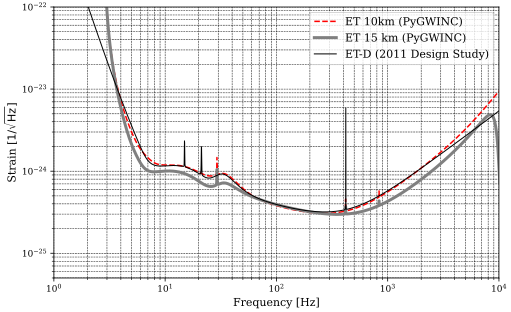

In [12]:
# Plot comparison of ET 10km vs. ET 15km
fig = plt.figure(figsize=(8,5))
plt.loglog(freq_ET,np.sqrt(ET_total),'r',linestyle='--',linewidth=1.5)
plt.loglog(freq_ET,np.sqrt(ET15_total),'gray',linewidth=3.0)
plt.loglog(Freq,C,'k',linewidth=1.0)

plt.grid(which='both',color='k',linestyle='--',linewidth=0.5)

plt.legend(['ET 10km (PyGWINC)','ET 15 km (PyGWINC)','ET-D (2011 Design Study)'],ncol=1)

plt.xlim(1,10000)

plt.ylim([5*10**(-26), 1*10**(-22)])

plt.xlabel('Frequency [Hz]')
plt.ylabel('Strain [$1 / \sqrt{\mathrm{Hz}}$]')
#plt.savefig("ET-D_comparison_.pdf")